# Task 2: Multi-class Classification — Fuel Type Detection

**Project:** Emissions from Above  
**Dataset:** US Power Plant Satellite Imagery Dataset (USPPDS) + EPA eGRID 2014

---

## Overview

Extend the binary classifier to a **multi-class** problem: predict the primary fuel category  
(coal, gas, oil, nuclear, hydro, wind/solar) directly from Landsat 8 satellite imagery.  
Fuel type is a strong proxy for emissions intensity and is visually distinguishable  
(cooling towers, solar arrays, wind turbines, stack configurations).

> **Goal:** Classify each satellite image into one of the fuel categories and explore  
> whether the model learns visually meaningful latent representations.


## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder

# Dimensionality reduction for embedding visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## 2. Configuration

In [ ]:
import sys
import os
import time
from google.colab import drive


drive.mount('/content/drive')

sys.path.append('/content/drive/My Drive/machine-learning-II/ML2FP')



DATA_ROOT   = Path("/content/drive/My Drive/machine-learning-II/ML2FP/data")
LANDSAT_DIR = DATA_ROOT / "uspp_landsat"
EGRID_XLSX  = DATA_ROOT / "eGRID2014_Data_v2_US_EPA_with_imagery_list_for_power_plants.xlsx"
OUTPUT_DIR  = Path("/content/drive/My Drive/machine-learning-II/ML2FP/outputs/task2_multiclass_clf")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Classes to include — merge rare classes into 'OTHER' for cleaner training
# Full set: GAS, SOLAR, HYDRO, WIND, BIOMASS, COAL, OIL, GEOTHERMAL, NUCLEAR, OTHF, OFSL
KEEP_CLASSES = ['GAS', 'SOLAR', 'HYDRO', 'WIND', 'COAL', 'OIL', 'BIOMASS', 'NUCLEAR']
MERGE_TO_OTHER = False    # If True, rare fuel types become class 'OTHER'
MIN_CLASS_SIZE = 20       # Drop classes with fewer than this many samples

IMG_SIZE    = 75
BATCH_SIZE  = 32
NUM_EPOCHS  = 40
LR          = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT     = 0.4


Mounted at /content/drive


## 3. Load eGRID & Prepare Labels

In [ ]:
egrid_raw = pd.read_excel(EGRID_XLSX, sheet_name="PLNT14", header=1)

relevant_cols = ['SEQPLT14', 'PNAME', 'PSTATABB', 'PLFUELCT', 'PLPRMFL',
                 'PLCO2AN', 'PLCO2RTA', 'NAMEPCAP', 'CAPFAC', 'LAT', 'LON']
available = [c for c in relevant_cols if c in egrid_raw.columns]
egrid = egrid_raw[available].copy()

img_col = [c for c in egrid_raw.columns if 'imagery' in c.lower() or 'status' in c.lower()]
if img_col:
    egrid['imagery_status'] = egrid_raw[img_col[0]]

egrid = egrid.dropna(subset=['SEQPLT14', 'PLFUELCT'])
egrid['SEQPLT14']  = egrid['SEQPLT14'].astype(int)
egrid['PLFUELCT']  = egrid['PLFUELCT'].str.strip().str.upper()

# Class filtering
if KEEP_CLASSES:
    if MERGE_TO_OTHER:
        egrid['fuel_class'] = egrid['PLFUELCT'].apply(
            lambda x: x if x in KEEP_CLASSES else 'OTHER')
    else:
        egrid = egrid[egrid['PLFUELCT'].isin(KEEP_CLASSES)].copy()
        egrid['fuel_class'] = egrid['PLFUELCT']
else:
    egrid['fuel_class'] = egrid['PLFUELCT']

# Remove tiny classes
class_sizes = egrid['fuel_class'].value_counts()
valid_classes = class_sizes[class_sizes >= MIN_CLASS_SIZE].index.tolist()
egrid = egrid[egrid['fuel_class'].isin(valid_classes)].copy()

print(f"Classes: {sorted(egrid['fuel_class'].unique())}")
print(f"\nClass distribution:\n{egrid['fuel_class'].value_counts()}")


Classes: ['BIOMASS', 'COAL', 'GAS', 'HYDRO', 'NUCLEAR', 'OIL', 'SOLAR', 'WIND']

Class distribution:
fuel_class
GAS        1900
SOLAR      1524
HYDRO      1494
WIND       1076
OIL         895
BIOMASS     799
COAL        524
NUCLEAR      65
Name: count, dtype: int64



8 classes: ['BIOMASS', 'COAL', 'GAS', 'HYDRO', 'NUCLEAR', 'OIL', 'SOLAR', 'WIND']


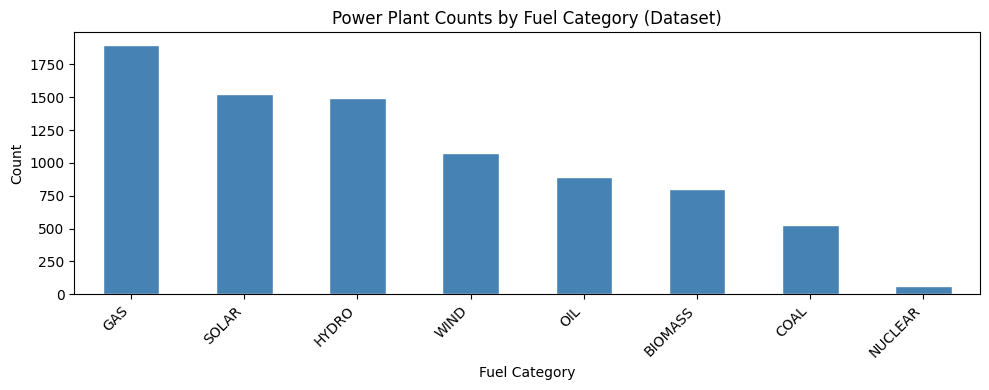

In [ ]:
# Encode labels
le = LabelEncoder()
egrid['label'] = le.fit_transform(egrid['fuel_class'])
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)
print(f"\n{N_CLASSES} classes: {CLASS_NAMES}")

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(10, 4))
egrid['fuel_class'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Power Plant Counts by Fuel Category (Dataset)')
ax.set_xlabel('Fuel Category'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150)
plt.show()


## 4. Image Path Resolution

In [ ]:
def build_landsat_path(row, base_dir):
    egrid_id = int(row['SEQPLT14'])
    state    = str(row.get('PSTATABB', 'XX')).strip().upper()
    fuel     = str(row.get('PLPRMFL', 'UNKN')).strip().upper()
    return base_dir / f"ls8_{egrid_id}_{state}_{fuel}.tif"

egrid['img_path']   = egrid.apply(build_landsat_path, axis=1, base_dir=LANDSAT_DIR)
egrid['img_exists'] = egrid['img_path'].apply(lambda p: p.exists())
egrid = egrid[egrid['img_exists']].reset_index(drop=True)

print(f"Images found: {len(egrid)} across {N_CLASSES} fuel classes")


Images found: 4311 across 8 fuel classes


## 5. Dataset & DataLoaders

In [ ]:
class FuelTypeDataset(Dataset):
    """Multi-class fuel type classification dataset."""

    def __init__(self, df, transform=None, n_bands=3):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.n_bands = n_bands

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with rasterio.open(row['img_path']) as src:
            bands = src.read()[:self.n_bands].astype(np.float32)
        for c in range(bands.shape[0]):
            ch = bands[c]; mn, mx = ch.min(), ch.max()
            bands[c] = (ch - mn) / (mx - mn + 1e-8)
        img_t = torch.from_numpy(bands)
        if self.transform:
            img_t = self.transform(img_t)
        return img_t, torch.tensor(row['label'], dtype=torch.long)


train_transform = T.Compose([
    T.Resize((64, 64), antialias=True),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
])
val_transform = T.Compose([T.Resize((64, 64), antialias=True)])

train_df, temp_df  = train_test_split(egrid, test_size=0.3, stratify=egrid['label'], random_state=SEED)
val_df,   test_df  = train_test_split(temp_df,  test_size=0.5, stratify=temp_df['label'],  random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Weighted sampler — critical for imbalanced classes (e.g., NUCLEAR=46 vs GAS=1160)
counts     = train_df['label'].value_counts().sort_index().values
weights    = [1.0 / counts[l] for l in train_df['label']]
sampler    = WeightedRandomSampler(weights, len(weights), replacement=True)

train_ds = FuelTypeDataset(train_df, train_transform)
val_ds   = FuelTypeDataset(val_df,   val_transform)
test_ds  = FuelTypeDataset(test_df,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)


Train: 3017 | Val: 647 | Test: 647


## 6. Model — EfficientNet-B0 Backbone

In [ ]:
def build_multiclass_model(n_input_channels=3, n_classes=8,
                           backbone='efficientnet_b0', dropout=0.4):
    if backbone == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if n_input_channels != 3:
            old = model.features[0][0]
            model.features[0][0] = nn.Conv2d(
                n_input_channels, old.out_channels,
                kernel_size=old.kernel_size, stride=old.stride, padding=old.padding, bias=False)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, n_classes))
    elif backbone == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(model.fc.in_features, n_classes))
    return model

model = build_multiclass_model(n_input_channels=3, n_classes=N_CLASSES,
                               backbone='efficientnet_b0', dropout=DROPOUT)
model = model.to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 351MB/s]


Parameters: 4,017,796


## 7. Training

In [ ]:
class_counts  = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)
optimizer     = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler     = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    n = sum(p == l for p, l in zip(all_preds, all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader.dataset), n / len(all_labels), macro_f1


history = {'tr_loss': [], 'vl_loss': [], 'tr_acc': [], 'vl_acc': [], 'vl_f1': []}
best_f1 = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc           = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_f1   = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1]): history[k].append(v)
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | TrLoss {tr_loss:.4f} TrAcc {tr_acc:.3f} | "
              f"VlLoss {vl_loss:.4f} VlAcc {vl_acc:.3f} VlF1 {vl_f1:.3f}")

print(f"\nBest Val Macro-F1: {best_f1:.4f}")


Epoch   1 | TrLoss 1.7873 TrAcc 0.184 | VlLoss 2.0551 VlAcc 0.114 VlF1 0.123
Epoch   5 | TrLoss 0.8808 TrAcc 0.347 | VlLoss 1.8411 VlAcc 0.241 VlF1 0.228
Epoch  10 | TrLoss 0.7239 TrAcc 0.459 | VlLoss 1.6939 VlAcc 0.303 VlF1 0.285
Epoch  15 | TrLoss 0.6543 TrAcc 0.514 | VlLoss 1.6163 VlAcc 0.368 VlF1 0.350
Epoch  20 | TrLoss 0.5863 TrAcc 0.544 | VlLoss 1.6163 VlAcc 0.368 VlF1 0.354
Epoch  25 | TrLoss 0.5378 TrAcc 0.578 | VlLoss 1.6601 VlAcc 0.365 VlF1 0.339
Epoch  30 | TrLoss 0.4930 TrAcc 0.602 | VlLoss 1.6588 VlAcc 0.372 VlF1 0.347
Epoch  35 | TrLoss 0.4561 TrAcc 0.610 | VlLoss 1.6697 VlAcc 0.396 VlF1 0.362
Epoch  40 | TrLoss 0.4986 TrAcc 0.580 | VlLoss 1.6072 VlAcc 0.388 VlF1 0.360

Best Val Macro-F1: 0.3619


## 8. Test Evaluation & Per-Class Report

In [ ]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print("=== Test Set Results ===")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))


=== Test Set Results ===
              precision    recall  f1-score   support

     BIOMASS       0.25      0.39      0.30        64
        COAL       0.25      0.51      0.33        53
         GAS       0.91      0.06      0.11       174
       HYDRO       0.68      0.68      0.68       104
     NUCLEAR       0.08      0.14      0.10         7
         OIL       0.19      0.57      0.29        49
       SOLAR       0.62      0.28      0.39       127
        WIND       0.45      0.67      0.53        69

    accuracy                           0.38       647
   macro avg       0.43      0.41      0.34       647
weighted avg       0.58      0.38      0.35       647



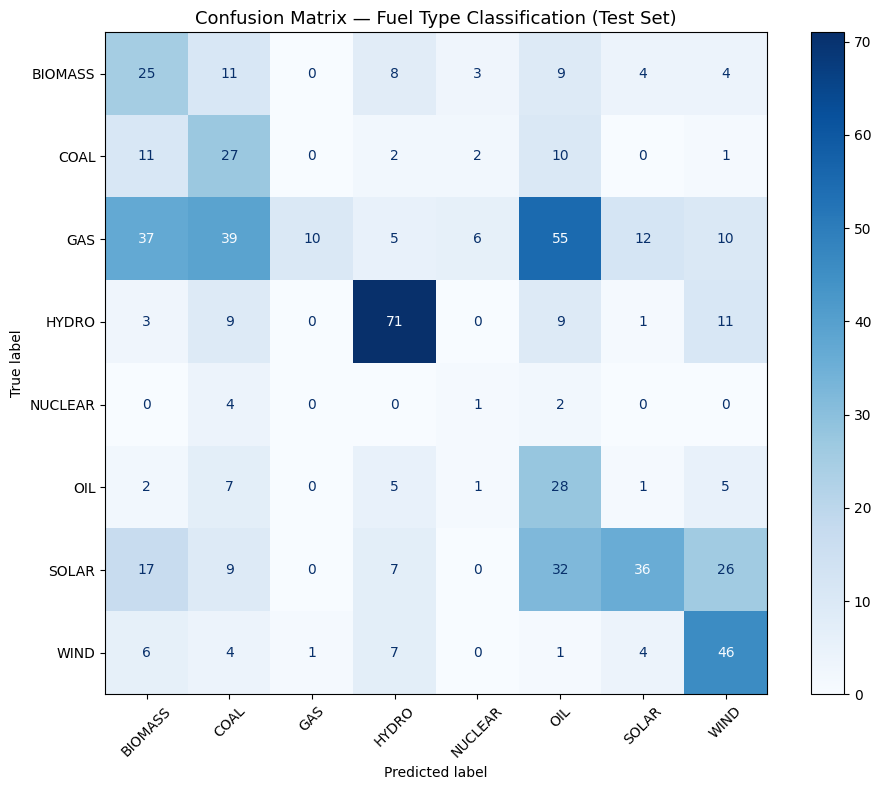

In [ ]:
# Confusion matrix — the key diagnostic for visual fuel-type separability
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Fuel Type Classification (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()


## 9. Feature Embedding Visualization (t-SNE / PCA)

In [ ]:
# Extract penultimate-layer embeddings to see if the CNN learns fuel-type structure

def extract_embeddings(model, loader):
    """Hook into the backbone before the classifier head."""
    embeddings, labels_all = [], []
    hooks = []

    captured = {}
    def hook_fn(module, input, output):
        captured['feat'] = output.detach().cpu()

    # EfficientNet: hook the avgpool output
    if hasattr(model, 'avgpool'):
        h = model.avgpool.register_forward_hook(hook_fn)
    else:
        h = model.features.register_forward_hook(hook_fn)
    hooks.append(h)

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            _ = model(imgs.to(device))
            feat = captured['feat'].view(imgs.size(0), -1).numpy()
            embeddings.append(feat)
            labels_all.extend(labels.numpy())

    for h in hooks: h.remove()
    return np.vstack(embeddings), np.array(labels_all)

print("Extracting embeddings from validation set...")
embs, emb_labels = extract_embeddings(model, val_loader)
print(f"Embedding shape: {embs.shape}")

# PCA first to 50 dims (speeds up t-SNE)
pca = PCA(n_components=min(50, embs.shape[1]), random_state=SEED)
embs_pca = pca.fit_transform(embs)
print(f"PCA explained variance (50 components): {pca.explained_variance_ratio_.sum():.2%}")

# t-SNE to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
embs_2d = tsne.fit_transform(embs_pca)
print("t-SNE done.")


Extracting embeddings from validation set...
Embedding shape: (647, 1280)
PCA explained variance (50 components): 42.73%
t-SNE done.


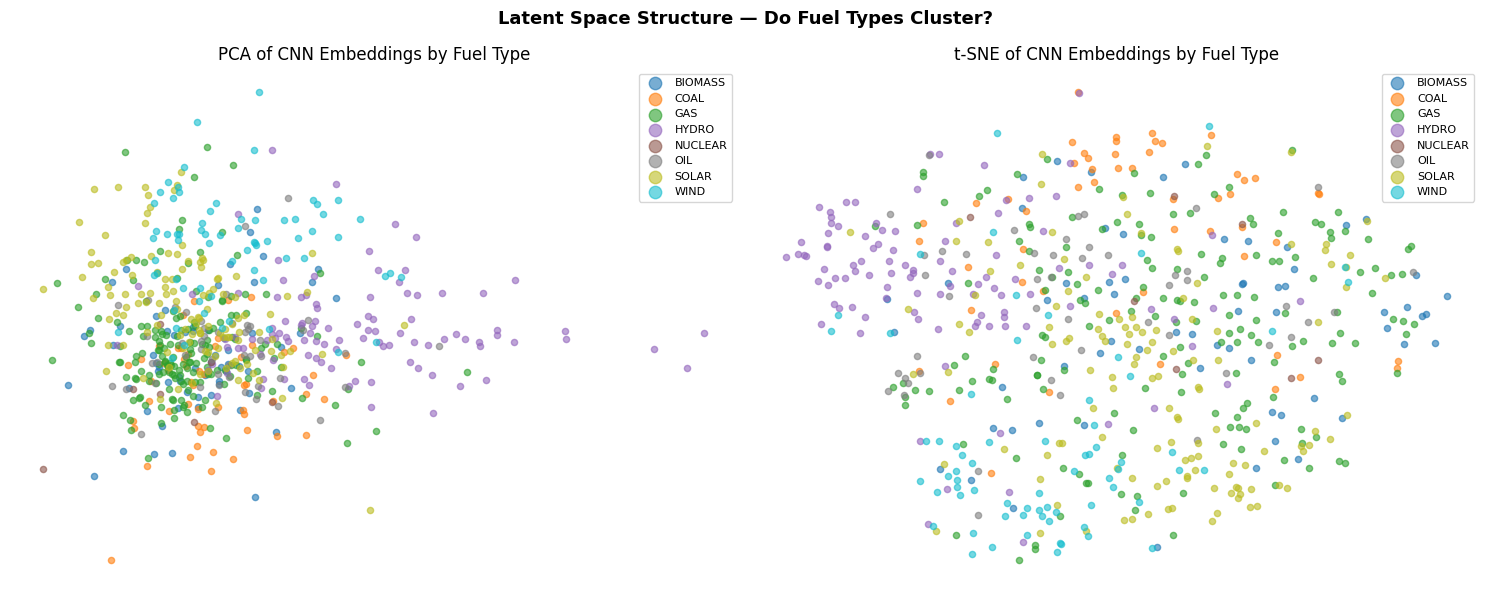

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = plt.cm.get_cmap('tab10', N_CLASSES)

for ax, (method, data) in zip(axes, [('PCA', embs_pca[:, :2]), ('t-SNE', embs_2d)]):
    for i, cls in enumerate(CLASS_NAMES):
        mask = emb_labels == i
        ax.scatter(data[mask, 0], data[mask, 1],
                   c=[palette(i)], label=cls, alpha=0.6, s=20)
    ax.set_title(f'{method} of CNN Embeddings by Fuel Type')
    ax.legend(fontsize=8, markerscale=2, loc='best')
    ax.axis('off')

plt.suptitle("Latent Space Structure — Do Fuel Types Cluster?", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'embedding_visualization.png', dpi=150)
plt.show()


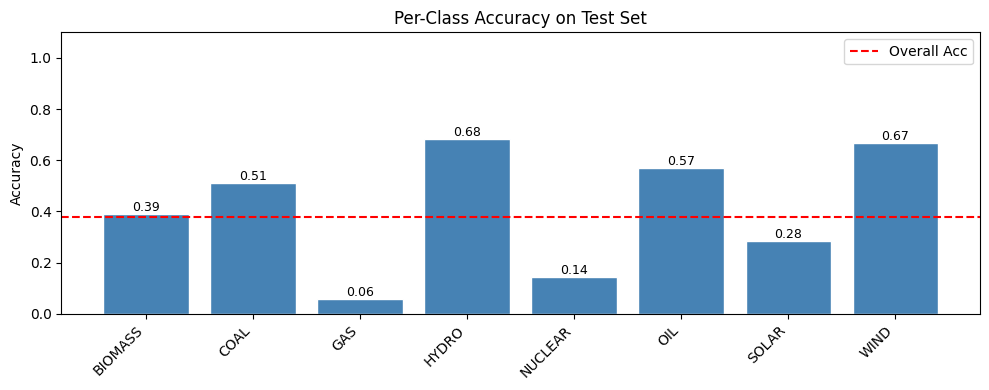

In [ ]:
# Per-class accuracy bar chart
per_class_acc = {}
for i, cls in enumerate(CLASS_NAMES):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        per_class_acc[cls] = (np.array(all_preds)[mask] == i).mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(per_class_acc.keys(), per_class_acc.values(), color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(accuracy_score(all_labels, all_preds), color='red', linestyle='--', label='Overall Acc')
ax.set_ylabel('Accuracy'); ax.set_title('Per-Class Accuracy on Test Set')
ax.legend(); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_accuracy.png', dpi=150)
plt.show()


## 10. Discussion & Next Steps

- **Visually distinguishable classes** (solar arrays, wind farms, coal stacks) should cluster cleanly in t-SNE.  
  Inspect misclassifications — e.g. GAS vs. OIL — as they may share visual signatures.
- **Data imbalance**: NUCLEAR (46 samples) will likely underperform. Consider few-shot techniques or  
  combining NUCLEAR+OTHF into a single class.
- **Band selection**: Adding Landsat thermal bands (B10/B11) should improve differentiation of  
  high-heat facilities (coal, nuclear) from renewables.
- **Connect to Task 1**: Use the predicted fuel type as an auxiliary feature in the regression model (Task 3).
- **Error analysis**: Manually inspect high-confidence wrong predictions — they often reveal  
  label noise or ambiguous plant configurations.
